Transform Matrix:
[[ 9.99999941e-01  3.44657476e-04  1.19899969e+02]
 [-3.44657476e-04  9.99999941e-01 -7.68565128e+01]]


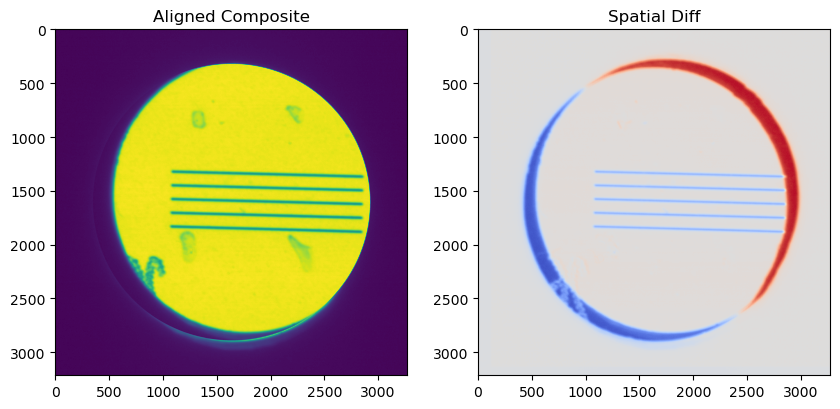

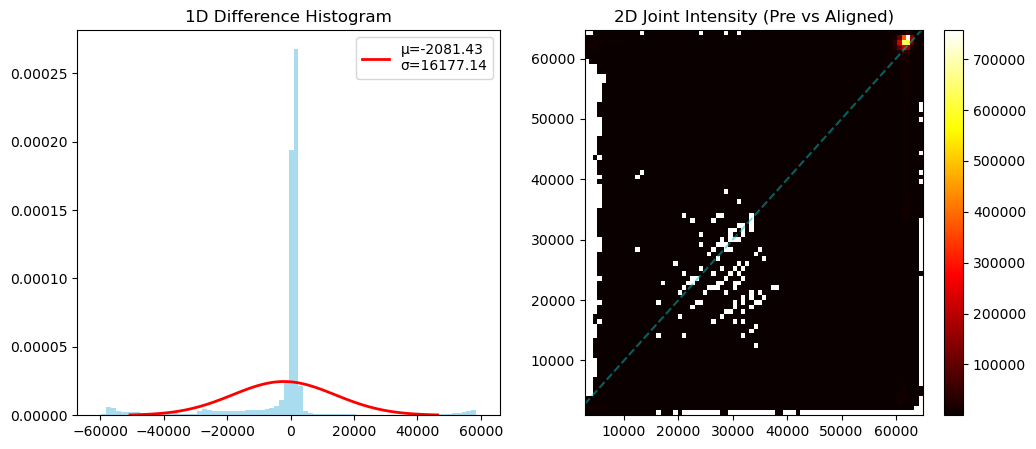

In [58]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
from scipy.stats import norm
from typing import Optional, List, Tuple

# ==========================================
# 1. LOADING & MARKER DETECTION
# ==========================================

def load_image_channel(path: str, file: str, channel: int):
    full_path = os.path.join(path, file)
    img = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise IOError(f"Could not read: {full_path}")
    
    if img.ndim == 2:
        selected = img.astype(np.float64)
    else:
        selected = img[..., channel].astype(np.float64)
    return selected, img

import cv2
import numpy as np

def detect_red_mask(image_bgr, sensitivity=1.0, min_area=5):
    """
    Detects red regions, filters by sensitivity and minimum area,
    and returns a clean binary mask.
    """
    # 1. Handle non-uint8 images (Normalization)
    if image_bgr.dtype != np.uint8:
        img_min, img_max = image_bgr.min(), image_bgr.max()
        img_norm = (image_bgr.astype(np.float32) - img_min) / (img_max - img_min + 1e-5)
        image_bgr_8 = (img_norm * 255).astype(np.uint8)
    else:
        image_bgr_8 = image_bgr

    # 2. Convert to HSV
    hsv = cv2.cvtColor(image_bgr_8, cv2.COLOR_BGR2HSV)

    # 3. Define sensitivity-based ranges
    low_sat = max(40, int(70 / sensitivity))
    hue_range = int(10 * sensitivity)
    
    # Threshold both red ranges (wrap-around)
    mask1 = cv2.inRange(hsv, np.array([0, low_sat, 50]), np.array([hue_range, 255, 255]))
    mask2 = cv2.inRange(hsv, np.array([180 - hue_range, low_sat, 50]), np.array([180, 255, 255]))
    mask = cv2.bitwise_or(mask1, mask2)

    # 4. Clean up initial noise (Opening)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    # 5. Filter by Area (The "Process" from the second function)
    # Find all connected blobs
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create an empty black mask to redraw only valid contours
    filtered_mask = np.zeros_like(mask)
    
    for cnt in contours:
        if cv2.contourArea(cnt) >= min_area:
            # Draw the valid "large" blobs back onto the filtered mask
            cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    # 6. Optional: Final Closing to fill small internal holes in the valid blobs
    return cv2.morphologyEx(filtered_mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

# ==========================================
# 2. MARKER PROCESSING & TRANSFORM
# ==========================================

def get_marker_centers(mask: np.ndarray, max_markers: int):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: raise RuntimeError("No red markers found.")
    
    # Sort by area and take top N
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:max_markers]
    centers = []
    for c in contours:
        M = cv2.moments(c)
        if M["m00"] != 0:
            centers.append([M["m10"] / M["m00"], M["m01"] / M["m00"]])
    return np.array(centers)

def match_points(src, dst):
    best_perm, min_dist = None, float('inf')
    for p in permutations(range(len(src))):
        d = np.sum((src[list(p)] - dst)**2)
        if d < min_dist: min_dist, best_perm = d, p
    return src[list(best_perm)]

def estimate_rigid_transform(src_pts, dst_pts):
    """Kabsch Algorithm for strict Rotation + Translation."""
    mu_s, mu_d = src_pts.mean(axis=0), dst_pts.mean(axis=0)
    S, D = src_pts - mu_s, dst_pts - mu_d
    H = S.T @ D
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[1, :] *= -1
        R = Vt.T @ U.T
    t = mu_d - R @ mu_s
    return np.hstack([R, t.reshape(2, 1)])

# ==========================================
# 3. ALIGNMENT & ERROR CHECKING
# ==========================================

def build_circle_mask(shape, radius_factor=0.4):
    h, w = shape
    yy, xx = np.mgrid[:h, :w]
    return ((xx - w/2)**2 + (yy - h/2)**2) <= (radius_factor * min(h, w))**2

def plot_analysis(pre, post, mask, title="Alignment Analysis"):
    pre_v, post_v = pre[mask], post[mask]
    diff = post_v - pre_v
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1D Histogram
    axes[0].hist(diff, bins=80, density=True, color='skyblue', alpha=0.7)
    mu, std = np.mean(diff), np.std(diff)
    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    axes[0].plot(x, norm.pdf(x, mu, std), 'r', lw=2, label=f'μ={mu:.2f}\nσ={std:.2f}')
    axes[0].set_title("1D Difference Histogram")
    axes[0].legend()

    # 2D Joint Histogram
    h2d = axes[1].hist2d(pre_v, post_v, bins=80, cmap='hot', cmin=1)
    axes[1].plot([pre_v.min(), pre_v.max()], [pre_v.min(), pre_v.max()], 'c--', alpha=0.5)
    axes[1].set_title("2D Joint Intensity (Pre vs Aligned)")
    plt.colorbar(h2d[3], ax=axes[1])
    plt.show()

# ==========================================
# 4. MAIN PIPELINE
# ==========================================

def run_full_alignment(path_pre, file_pre, path_post, file_post):
    # 1. Load Data
    pre_chan, pre_col = load_image_channel(path_pre, file_pre, 2)
    post_chan, post_col = load_image_channel(path_post, file_post, 2)
    
    # Resize post to pre
    if pre_chan.shape != post_chan.shape:
        post_col = cv2.resize(post_col, (pre_chan.shape[1], pre_chan.shape[0]))
        post_chan = cv2.resize(post_chan, (pre_chan.shape[1], pre_chan.shape[0]))

    # 2. Detect & Match Markers
    mask_pre = detect_red_mask(pre_col,sensitivity=1.5)
    mask_post = detect_red_mask(post_col,sensitivity=1.5)

    pts_pre = get_marker_centers(mask_pre, 4)
    pts_post = get_marker_centers(mask_post, 4)
    
    # Ensure equal number of points
    n = min(len(pts_pre), len(pts_post))
    pts_pre, pts_post = pts_pre[:n], pts_post[:n]
    pts_post_matched = match_points(pts_post, pts_pre)

    # 3. Calculate M_rigid (The Transform Matrix)
    M_rigid = estimate_rigid_transform(pts_post_matched, pts_pre)
    print(f"Transform Matrix:\n{M_rigid}")

    # 4. Apply Translation & Rotation (Fixes your current issue)
    h, w = pre_chan.shape
    aligned_post = cv2.warpAffine(post_chan, M_rigid, (w, h), flags=cv2.INTER_LINEAR)
    
    # 5. Composite and Error Check
    roi_mask = build_circle_mask(pre_chan.shape, 0.4)
    
    # Create spatial display
    composite = pre_chan.copy()
    composite[roi_mask] = aligned_post[roi_mask]
    
    plt.figure(figsize=(10, 5))
    plt.subplot(121); plt.imshow(composite, cmap='viridis'); plt.title("Aligned Composite")
    plt.subplot(122); plt.imshow(aligned_post - pre_chan, cmap='coolwarm'); plt.title("Spatial Diff")
    plt.show()

    # Run Histograms
    plot_analysis(pre_chan, aligned_post, roi_mask)
    return M_rigid

# Example Usage:
path_pre = "/home/michaelgajda/cal_Lab_Work/analysis_code/Northwestern_film_analysis_version_1/scans/1218/raw"
file_pre = "pre_Northwestern_1218_042_cut_5.tif"
path_post = "/home/michaelgajda/cal_Lab_Work/analysis_code/Northwestern_film_analysis_version_1/scans/1218/raw"
file_post = "post_Northwestern_1218_013_cut_5.tif"
pre = path_pre + "/" + file_pre
post = path_post + "/" + file_post
M_rigid = run_full_alignment(path_pre = "/home/michaelgajda/cal_Lab_Work/analysis_code/Northwestern_film_analysis_version_1/scans/1218/raw",
    file_pre = "pre_Northwestern_1218_042_cut_5.tif",
    path_post = "/home/michaelgajda/cal_Lab_Work/analysis_code/Northwestern_film_analysis_version_1/scans/1218/raw",
    file_post = "post_Northwestern_1218_013_cut_5.tif")

In [2]:
import numpy as np

# Load the array from the .npy file
data = np.load('/home/michaelgajda/cal_Lab_Work/analysis_code/Northwestern_film_analysis_version_1/code/stats/post_Northwestern_1218_013_stats.npy', allow_pickle=True)

my_dict_post = data.item()

data = np.load('/home/michaelgajda/cal_Lab_Work/analysis_code/Northwestern_film_analysis_version_1/code/stats/pre_Northwestern_1218_042_stats.npy', allow_pickle=True)

my_dict_pre = data.item()

In [ ]:
def dose_Calculation_from_OD_diff(OD_diff):
    """
    Calculate dose from optical density difference using a calibration curve.

    OD_diff: Optical density difference (float or np.ndarray)

    Returns:
        dose: Calculated dose (same shape as OD_diff)
    """
    # Calibration parameters (example values, replace with actual calibration data)
    a = 8.7705
    b = -8.0102
    c= 9.3871
    d= -.5839

    # Calculate dose using the cubic calibration curve
    dose = a * OD_diff**3 + b * OD_diff**2 + c * OD_diff + d
    return doseBartzsch, S., Lott, J., Welsch, K., Bräuer-Krisch, E. and Oelfke, U. (2015), Micrometer-resolved film dosimetry using a microscope in microbeam radiation therapy. Med. Phys., 42: 4069-4079. https://doi.org/10.1118/1.4922001

In [3]:
def polyfit_linear(x: np.ndarray, y: np.ndarray):
    p = np.polyfit(x, y, 1)
    yfit = np.polyval(p, x)
    resid = y - yfit
    S = {"resid": resid, "yfit": yfit}
    return p, S

def poly_apply(p: np.ndarray, x: np.ndarray):
    return np.polyval(p, x), None

def scanner_to_OD(pv: np.ndarray, max_val: float = (2**16 - 1)) -> np.ndarray:
    """Scanner OD = log10((max) / PV). Avoid log of zero."""
    pv = pv.astype(np.float64)
    pv = np.clip(pv, 1, max_val)    
    return np.log10(max_val / pv)

In [4]:
def polyfit_linear(x: np.ndarray, y: np.ndarray):
    p = np.polyfit(x, y, 1)
    yfit = np.polyval(p, x)
    resid = y - yfit
    S = {"resid": resid, "yfit": yfit}
    return p, S

def poly_apply(p: np.ndarray, x: np.ndarray):
    return np.polyval(p, x), None

def scanner_to_OD(pv: np.ndarray, max_val: float = (2**16 - 1)) -> np.ndarray:
    """Scanner OD = log10((max) / PV). Avoid log of zero."""
    pv = pv.astype(np.float64)
    pv = np.clip(pv, 1, max_val)

def compute_calibrated_OD_values(
    film_masks_pre: list[np.ndarray],
    film_masks_post: list[np.ndarray],
    full_img_pre: np.ndarray,
    full_img_post: np.ndarray,
    P_pre: np.ndarray,
    P_post: np.ndarray,
    scanner_to_OD,
    poly_apply
) -> tuple[
    list[np.ndarray],  # 1D pre values
    list[np.ndarray],  # 1D post values
    list[np.ndarray],  # 2D pre maps (masked)
    list[np.ndarray]   # 2D post maps (masked)
]:
    """
    Compute calibrated OD values for each ROI.

    Returns:
        - OD_pre_vals_1d: list of 1D OD arrays (ROI-only values)
        - OD_post_vals_1d: list of 1D OD arrays
        - OD_pre_maps_2d: list of 2D OD maps with NaN outside ROI
        - OD_post_maps_2d: list of 2D OD maps with NaN outside ROI
    """

    OD_pre_vals = []
    OD_post_vals = []
    OD_pre_maps = []
    OD_post_maps = []

    for i, (mask_pre, mask_post) in enumerate(zip(film_masks_pre, film_masks_post)):
        # Use common mask to enforce matching ROI
        common_mask = mask_pre & mask_post

        if not np.any(common_mask):
            print(f"[Warning] Empty ROI at index {i} — skipping.")
            continue

        # Get pixel values inside ROI only (flattened)
        pre_vals = full_img_pre[common_mask]
        post_vals = full_img_post[common_mask]

        # Convert pixel values to OD
        OD_pre = scanner_to_OD(pre_vals)
        OD_post = scanner_to_OD(post_vals)

        # Apply calibration polynomials
        OD_pre_cal, _ = poly_apply(P_pre, OD_pre)
        OD_post_cal, _ = poly_apply(P_post, OD_post)

        # Filter out low OD values
        valid_mask = (OD_pre_cal >= 0.15) & (OD_post_cal >= 0.15)
        if not np.any(valid_mask):
            print(f"[Info] Skipped ROI {i} — all OD values < 0.15.")
            continue

        # Store 1D calibrated OD values
        OD_pre_vals.append(OD_pre_cal[valid_mask])
        OD_post_vals.append(OD_post_cal[valid_mask])

        # --- Create full-size 2D maps masked with NaN outside ROI ---

        # Convert full image to OD and calibrate
        full_OD_pre = scanner_to_OD(full_img_pre)
        full_OD_post = scanner_to_OD(full_img_post)

        full_OD_pre_cal, _ = poly_apply(P_pre, full_OD_pre)
        full_OD_post_cal, _ = poly_apply(P_post, full_OD_post)

        # Create masked 2D OD maps (NaN outside mask)
        OD_pre_map = np.full_like(full_OD_pre_cal, np.nan, dtype=np.float64)
        OD_post_map = np.full_like(full_OD_post_cal, np.nan, dtype=np.float64)

        OD_pre_map[common_mask] = full_OD_pre_cal[common_mask]
        OD_post_map[common_mask] = full_OD_post_cal[common_mask]

        OD_pre_maps.append(OD_pre_map)
        OD_post_maps.append(OD_post_map)

    return OD_pre_vals, OD_post_vals, OD_pre_maps, OD_post_maps

<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:95: SyntaxWarning: invalid escape sequence '\s'
<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:95: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_413669/812392927.py:75: SyntaxWarning: invalid escape sequence '\m'
  axes[1, 0].plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label=f'$\mu$={mu:.2e}\n$\sigma$={std:.2e}')
/tmp/ipykernel_413669/812392927.py:75: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label=f'$\mu$={mu:.2e}\n$\sigma$={std:.2e}')
/tmp/ipykernel_413669/812392927.py:95: SyntaxWarning: invalid escape sequence '\s'
  f"Std Dev ($\sigma$): {std:.4e}\n"


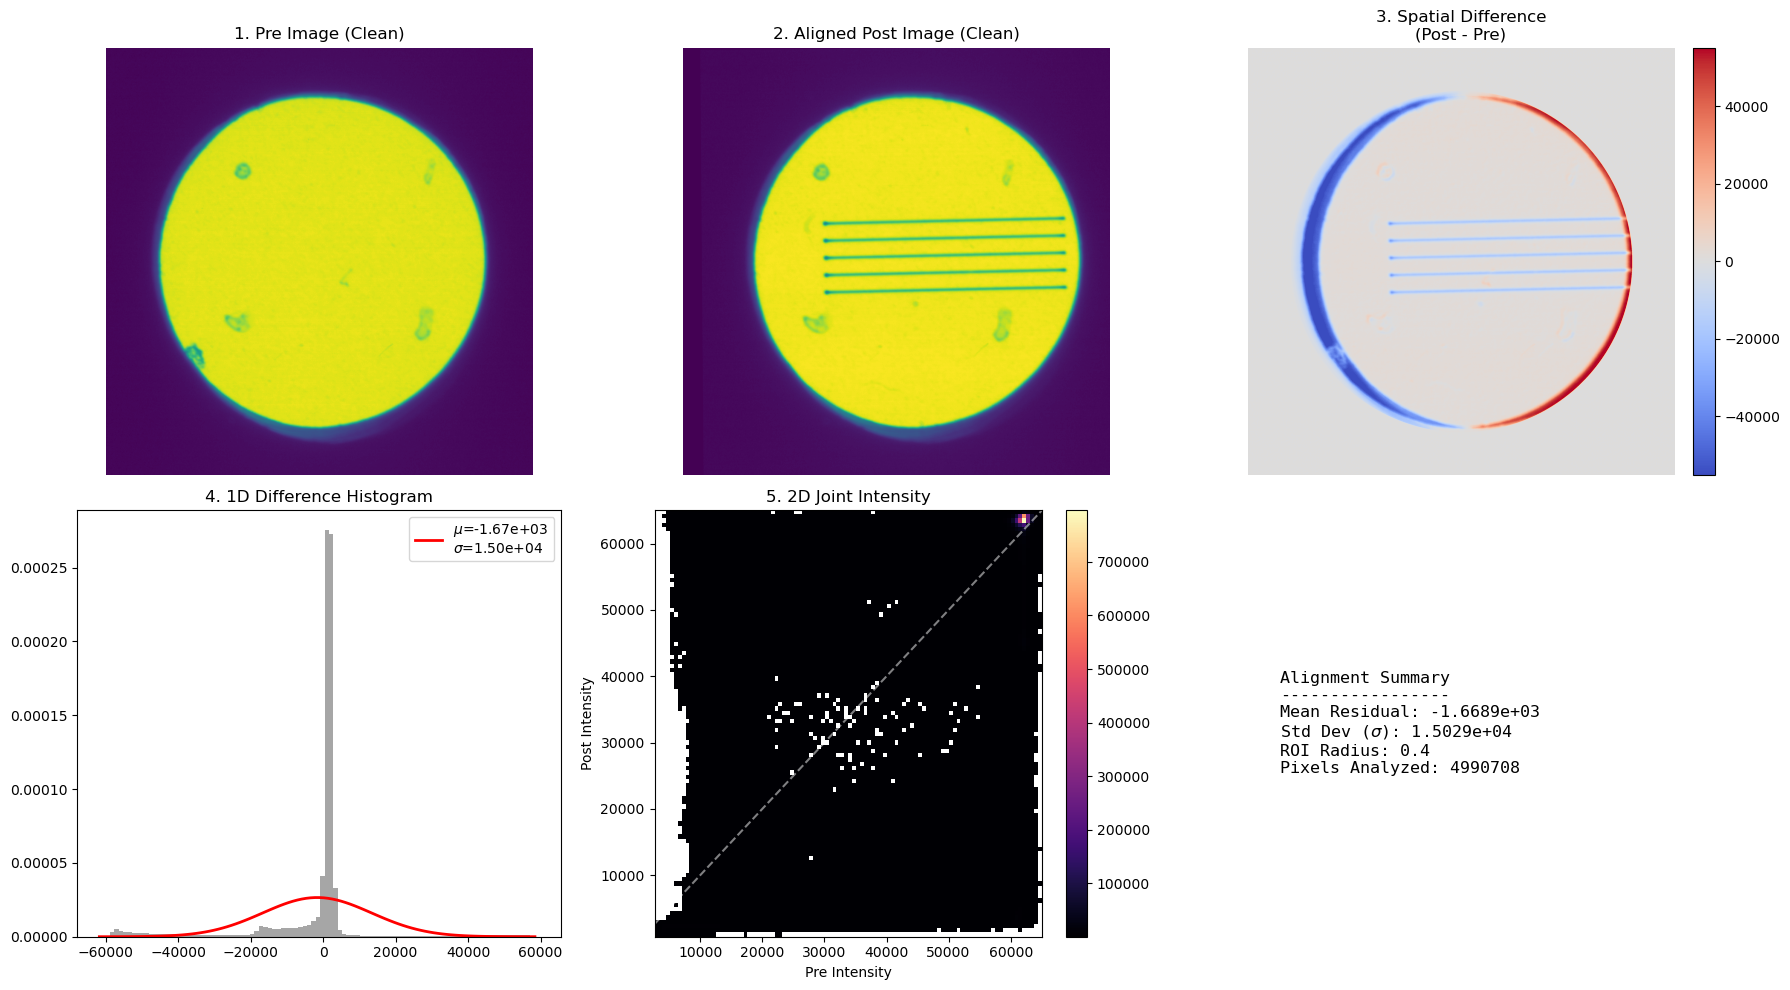

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. LOAD THE DATA (Assuming .npy dictionary or TIFF)
# We load the "Data" channel (e.g. Blue/Green) to avoid the Red markers
def get_clean_data(file_path):
    # If loading from a .npy dictionary:
    # data_dict = np.load(file_path, allow_pickle=True).item()
    # return data_dict['image_data'] 
    
    # If loading from a TIFF (Channel 0 = Blue, usually clean of red marks):
    img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
    return img[..., 2].astype(np.float64)

# 2. APPLY THE TRANSFORM
def align_clean_image(pre_data, post_data, M_rigid):
    """
    Applies the translation and rotation to the post_data.
    M_rigid is the 2x3 matrix calculated from the red markers.
    """
    h, w = pre_data.shape
    # cv2.warpAffine applies the rotation AND translation simultaneously
    aligned_post = cv2.warpAffine(
        post_data, 
        M_rigid, 
        (w, h), 
        flags=cv2.INTER_LINEAR
    )
    return aligned_post

# 3. ERROR CHECKING (The 1D and 2D Histograms)
def run_error_analysis(pre, post, radius_factor=0.4):
    """
    Displays a 5-panel diagnostic dashboard:
    Top Row: Pre, Aligned Post, Spatial Difference
    Bottom Row: 1D Difference Histogram, 2D Joint Intensity Histogram
    """
    h, w = pre.shape
    yy, xx = np.mgrid[:h, :w]
    roi_mask = ((xx - w/2)**2 + (yy - h/2)**2) <= (radius_factor * min(h, w))**2
    
    pre_samples = pre[roi_mask]
    post_samples = post[roi_mask]
    diff_vals = post_samples - pre_samples

    # Create a 2x3 grid (leaving the last slot for stats or blank)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # --- PANEL 1: PRE IMAGE ---
    axes[0, 0].imshow(pre, cmap='viridis')
    axes[0, 0].set_title("1. Pre Image (Clean)")
    axes[0, 0].axis('off')

    # --- PANEL 2: ALIGNED POST IMAGE ---
    axes[0, 1].imshow(post, cmap='viridis')
    axes[0, 1].set_title("2. Aligned Post Image (Clean)")
    axes[0, 1].axis('off')

    # --- PANEL 3: SPATIAL DIFFERENCE ---
    diff_map = np.zeros_like(pre)
    diff_map[roi_mask] = post[roi_mask] - pre[roi_mask]
    # Percentile clipping (98th) for better contrast
    vlim = np.percentile(np.abs(diff_vals), 98) if diff_vals.size > 0 else 1.0
    im_diff = axes[0, 2].imshow(diff_map, cmap='coolwarm', vmin=-vlim, vmax=vlim)
    axes[0, 2].set_title("3. Spatial Difference\n(Post - Pre)")
    axes[0, 2].axis('off')
    plt.colorbar(im_diff, ax=axes[0, 2], fraction=0.046, pad=0.04)

    # --- PANEL 4: 1D DIFFERENCE HISTOGRAM ---
    axes[1, 0].hist(diff_vals, bins=100, density=True, color='gray', alpha=0.7)
    mu, std = np.mean(diff_vals), np.std(diff_vals)
    x = np.linspace(mu - 4*std, mu + 4*std, 100)
    axes[1, 0].plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label=f'$\mu$={mu:.2e}\n$\sigma$={std:.2e}')
    axes[1, 0].set_title("4. 1D Difference Histogram")
    axes[1, 0].legend()

    # --- PANEL 5: 2D JOINT INTENSITY ---
    h2d = axes[1, 1].hist2d(pre_samples, post_samples, bins=100, cmap='magma', cmin=1)
    # The identity line y=x (ideal alignment)
    axes[1, 1].plot([pre_samples.min(), pre_samples.max()], 
                   [pre_samples.min(), pre_samples.max()], 'w--', alpha=0.5, label='Ideal ($y=x$)')
    axes[1, 1].set_title("5. 2D Joint Intensity")
    axes[1, 1].set_xlabel("Pre Intensity")
    axes[1, 1].set_ylabel("Post Intensity")
    plt.colorbar(h2d[3], ax=axes[1, 1])

    # --- PANEL 6: SUMMARY STATISTICS ---
    axes[1, 2].axis('off')
    stats_text = (
        f"Alignment Summary\n"
        f"-----------------\n"
        f"Mean Residual: {mu:.4e}\n"
        f"Std Dev ($\sigma$): {std:.4e}\n"
        f"ROI Radius: {radius_factor}\n"
        f"Pixels Analyzed: {len(diff_vals)}"
    )
    axes[1, 2].text(0.1, 0.5, stats_text, fontsize=12, family='monospace', verticalalignment='center')

    plt.tight_layout()
    plt.show()
# ==========================================
# EXECUTION
# ==========================================

# 1. Assume M_rigid was calculated previously from red markers
# (Make sure you have M_rigid from your previous Kabsch step)

# 2. Load the clean images (Red channel excluded)
pre_clean = get_clean_data(pre)
post_clean = get_clean_data(post)

# 3. Apply the rotation + translation to the post image
aligned_post_clean = align_clean_image(pre_clean, post_clean, M_rigid)

# 4. Final Comparison & Error Histogram
run_error_analysis(pre_clean, aligned_post_clean)

In [8]:
import cv2
import matplotlib.pyplot as plt
import os

# Define your paths (using the variables from your notebook)


# 1. Load the image with all channels
# IMREAD_UNCHANGED preserves bit-depth
img = cv2.imread(post, cv2.IMREAD_UNCHANGED)

if img is None:
    print(f"Error: Could not read it")
else:
    # 2. Exclude the Red channel
            # Make a copy to avoid modifying the original
        no_red = img.copy()
        no_green = img.copy()
        no_blue = img.copy()

        # OpenCV uses BGR order
        no_red[:, :, 2] = 0     # Remove Red channel
        no_green[:, :, 1] = 0   # Remove Green channel
        no_blue[:, :, 0] = 0    # Remove Blue channel

        # Display results
        cv2.imshow("Original", img)
        cv2.imshow("No Red", no_red)
        cv2.imshow("No Green", no_green)
        cv2.imshow("No Blue", no_blue)

    

QSocketNotifier: Can only be used with threads started with QThread


<>:137: SyntaxWarning: invalid escape sequence '\m'
<>:137: SyntaxWarning: invalid escape sequence '\s'
<>:137: SyntaxWarning: invalid escape sequence '\m'
<>:137: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_413669/4174719780.py:137: SyntaxWarning: invalid escape sequence '\m'
  axes[1, 0].plot(x_range, norm.pdf(x_range, mu, std), 'r-', label=f'$\mu$={mu:.2e}\n$\sigma$={std:.2e}')
/tmp/ipykernel_413669/4174719780.py:137: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].plot(x_range, norm.pdf(x_range, mu, std), 'r-', label=f'$\mu$={mu:.2e}\n$\sigma$={std:.2e}')


[[ 9.99969296e-01  7.83623042e-03  1.26453613e+02]
 [-7.83623042e-03  9.99969296e-01  1.29103572e+01]]
17146609.435850367
[1.87808296 0.23518381]
19543628.99700418
[1.83500642 0.26108425]


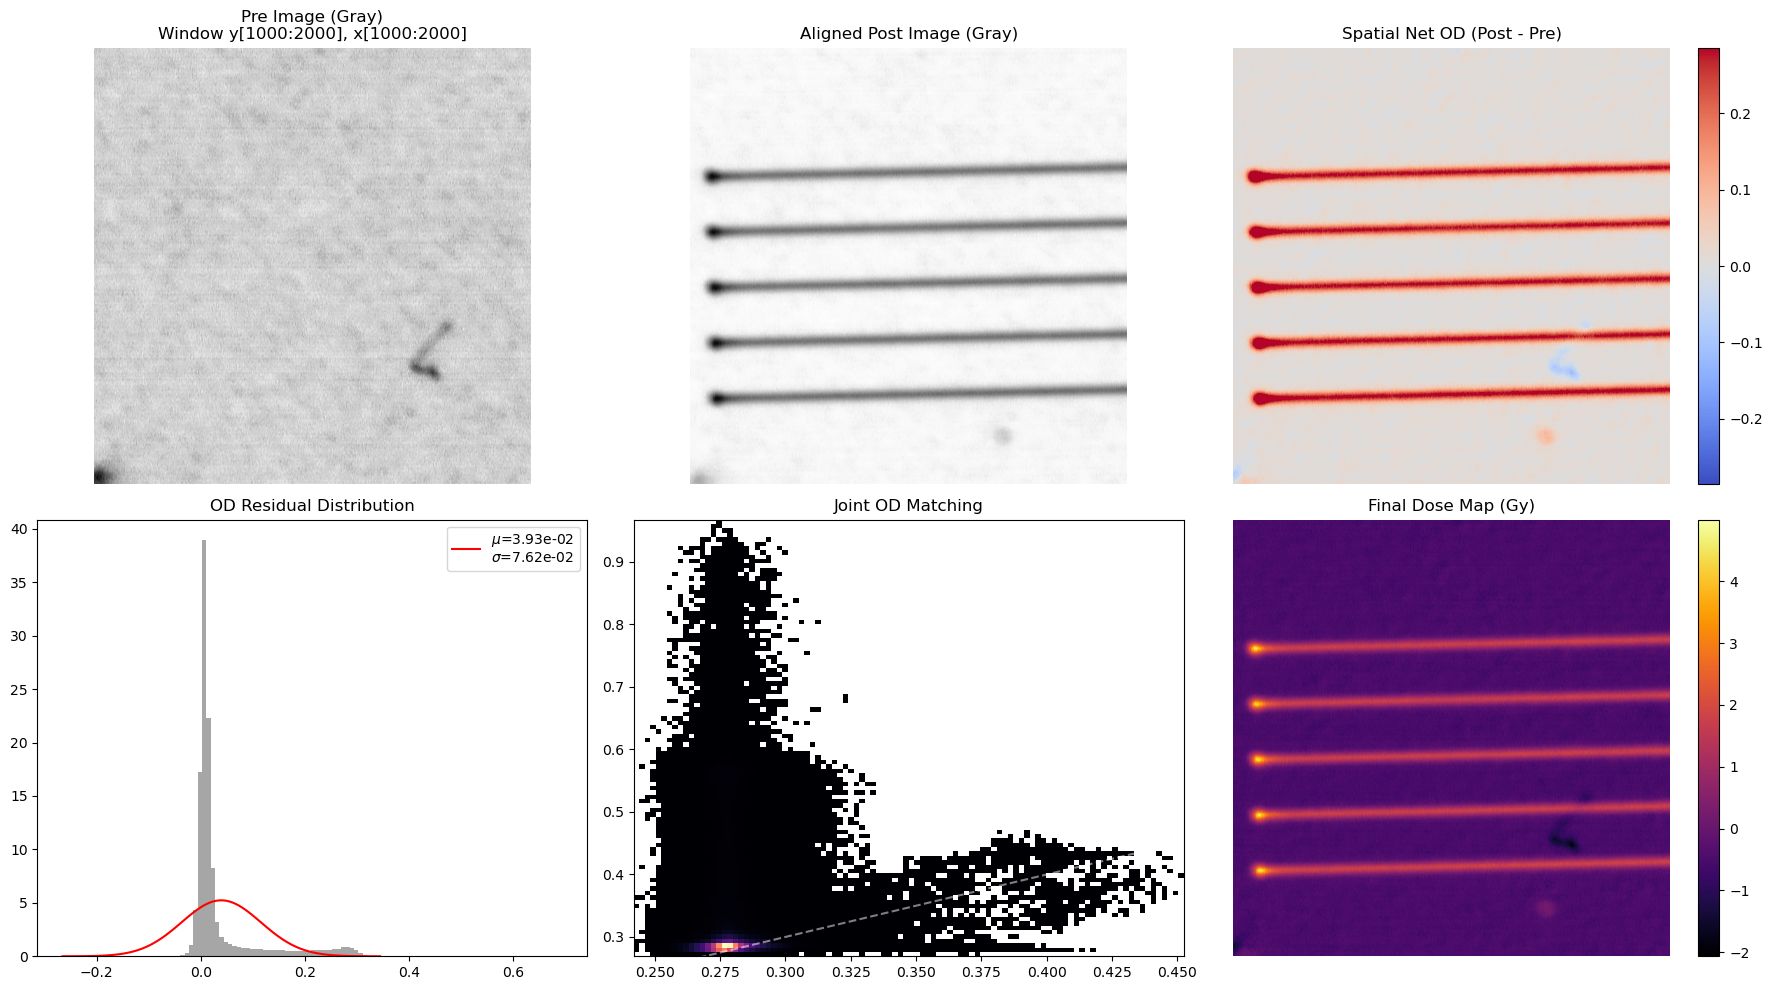

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from scipy.stats import norm

# ==========================================
# 1. USER PROVIDED FUNCTIONS
# ==========================================

def dose_Calculation_from_OD_diff(OD_diff):
    """Calculate dose from OD difference using cubic calibration."""
    a, b, c, d = 8.7705, -8.0102, 9.3871, -0.5839
    return a * OD_diff**3 + b * OD_diff**2 + c * OD_diff + d

def scanner_to_OD(pv: np.ndarray, max_val: float = (2**16 - 1)) -> np.ndarray:
    """Convert pixel values to Optical Density."""
    pv = pv.astype(np.float64)
    pv = np.clip(pv, 1, max_val)
    return np.log10(max_val / pv)

def poly_apply(p: np.ndarray, x: np.ndarray):
    """Apply polynomial calibration p to data x."""
    return np.polyval(p, x), None

# ==========================================
# 2. UPDATED LOADING & ALIGNMENT LOGIC
# ==========================================

def get_clean_aligned_data(pre, post, M_rigid):
    """
    Loads clean (Blue) channels and aligns the Post image to the Pre image.
    """
    # Load Pre (Channel 0 = Blue to avoid Red markers)
    img_pre = cv2.imread(pre, cv2.IMREAD_UNCHANGED)
    pre_clean = img_pre[..., 2].astype(np.float64) 

    # Load Post (Channel 0)
    img_post = cv2.imread(post, cv2.IMREAD_UNCHANGED)
    post_clean = img_post[..., 2].astype(np.float64) 

    # Apply M_rigid to align Post to Pre
    h, w = pre_clean.shape
    aligned_post = cv2.warpAffine(post_clean, M_rigid, (w, h), flags=cv2.INTER_LINEAR)
    
    return pre_clean, aligned_post

# ==========================================
# 3. INTEGRATED CALCULATION & ANALYSIS
# ==========================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from scipy.stats import norm

# ==========================================
# 1. CALIBRATION & DOSE FUNCTIONS
# ==========================================

def scanner_to_OD(pv: np.ndarray, max_val: float = (2**16 - 1)) -> np.ndarray:
    """Scanner OD = log10(max / PV)."""
    pv = pv.astype(np.float64)
    pv = np.clip(pv, 1, max_val)
    return np.log10(max_val / pv)

def poly_apply(p: np.ndarray, x: np.ndarray):
    """Apply polynomial calibration."""
    return np.polyval(p, x), None

def dose_Calculation_from_OD_diff(OD_diff):
    """Cubic calibration for Dose."""
    a, b, c, d = 8.7705, -8.0102, 9.3871, -0.5839
    return a * OD_diff**3 + b * OD_diff**2 + c * OD_diff + d

# ==========================================
# 2. ANALYSIS FUNCTION WITH WINDOW RESTRICTION
# ==========================================

def run_restricted_analysis(pre_full, post_aligned_full, y_range=(1000, 2000), x_range=(1000, 2000), P_pre=[1,0], P_post=[1,0]):
    """
    Crops the images to the specified range and performs 
    Dose and Error analysis on that window.
    """
    # Define the target window
    y1, y2 = 1000, 2000
    x1, x2 = 1000, 2000

    # 1. ALIGN FULL FRAME
    # Warp the post image to match the pre image geometry
    h, w = pre_full.shape


    # 2. CALCULATE FULL OD VALUES
    # Convert both full images to OD and apply calibration polynomials
    od_pre_full = np.polyval(P_pre, scanner_to_OD(pre_full))
    print(np.sum(od_pre_full))
    print(P_pre)
    od_post_full = np.polyval(P_post, scanner_to_OD(post_aligned_full))
    print(np.sum(od_post_full))
    print(P_post)
    # 3. APPLY SPATIAL CUTS (1000 to 2000)
    # Cut the actual intensity images for display
    pre_display_crop = pre_full[y1:y2, x1:x2]
    post_display_crop = post_aligned_full[y1:y2, x1:x2]
    
    # Cut the OD values for dose calculation
    od_pre_crop = od_pre_full[y1:y2, x1:x2]
    od_post_crop = od_post_full[y1:y2, x1:x2]

    # 4. DOSE CALCULATION
    od_diff = od_post_crop - od_pre_crop
    dose_map = dose_Calculation_from_OD_diff(od_diff)

    # 5. VISUALIZATION DASHBOARD
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Actual Images (Grayscale)
    axes[0, 0].imshow(pre_display_crop, cmap='gray')
    axes[0, 0].set_title(f"Pre Image (Gray)\nWindow y[{y1}:{y2}], x[{x1}:{x2}]")
    
    axes[0, 1].imshow(post_display_crop, cmap='gray')
    axes[0, 1].set_title("Aligned Post Image (Gray)")

    # Spatial Difference in OD
    vlim = np.percentile(np.abs(od_diff), 98)
    im_diff = axes[0, 2].imshow(od_diff, cmap='coolwarm', vmin=-vlim, vmax=vlim)
    axes[0, 2].set_title("Spatial Net OD (Post - Pre)")
    plt.colorbar(im_diff, ax=axes[0, 2])

    # 1D Residuals Histogram (OD units)
    diff_flat = od_diff.flatten()
    axes[1, 0].hist(diff_flat, bins=100, density=True, color='gray', alpha=0.7)
    mu, std = np.mean(diff_flat), np.std(diff_flat)
    x_range = np.linspace(mu - 4*std, mu + 4*std, 100)
    axes[1, 0].plot(x_range, norm.pdf(x_range, mu, std), 'r-', label=f'$\mu$={mu:.2e}\n$\sigma$={std:.2e}')
    axes[1, 0].set_title("OD Residual Distribution")
    axes[1, 0].legend()

    # 2D Joint Intensity (OD Space)
    axes[1, 1].hist2d(od_pre_crop.flatten(), od_post_crop.flatten(), bins=100, cmap='magma', cmin=1)
    axes[1, 1].plot([od_pre_crop.min(), od_pre_crop.max()], 
                   [od_pre_crop.min(), od_pre_crop.max()], 'w--', alpha=0.5)
    axes[1, 1].set_title("Joint OD Matching")

    # Dose Map
    im_dose = axes[1, 2].imshow(dose_map, cmap='inferno')
    axes[1, 2].set_title("Final Dose Map (Gy)")
    plt.colorbar(im_dose, ax=axes[1, 2])

    # Turn off axes for images
    for ax in [axes[0,0], axes[0,1], axes[0,2], axes[1,2]]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    return dose_map

# ==========================================
# 4. EXECUTION EXAMPLE
# ==========================================


# 1. Load and Align
print(M_rigid)
pre_data, post_aligned = get_clean_aligned_data(pre, post, M_rigid)


# 2. Calculate Dose and Display
P_pre =  my_dict_pre['P']  # Example: [1.0, 0.0]
P_post = my_dict_post['P']  # Example: [1.0, 0.0]
dose_results = run_restricted_analysis(pre_data, post_aligned, P_pre=P_pre, P_post=P_post)

In [30]:
print(np.sum(pre_data))
print(np.sum(post_aligned))

301335446851.0
303929592862.72266


Line 1: Center=203.25, Sigma=7.45, 2.5σ Width=37.25
Line 2: Center=330.25, Sigma=8.21, 2.5σ Width=41.06
Line 3: Center=457.79, Sigma=8.72, 2.5σ Width=43.58
Line 4: Center=585.44, Sigma=8.21, 2.5σ Width=41.05
Line 5: Center=712.44, Sigma=7.86, 2.5σ Width=39.31


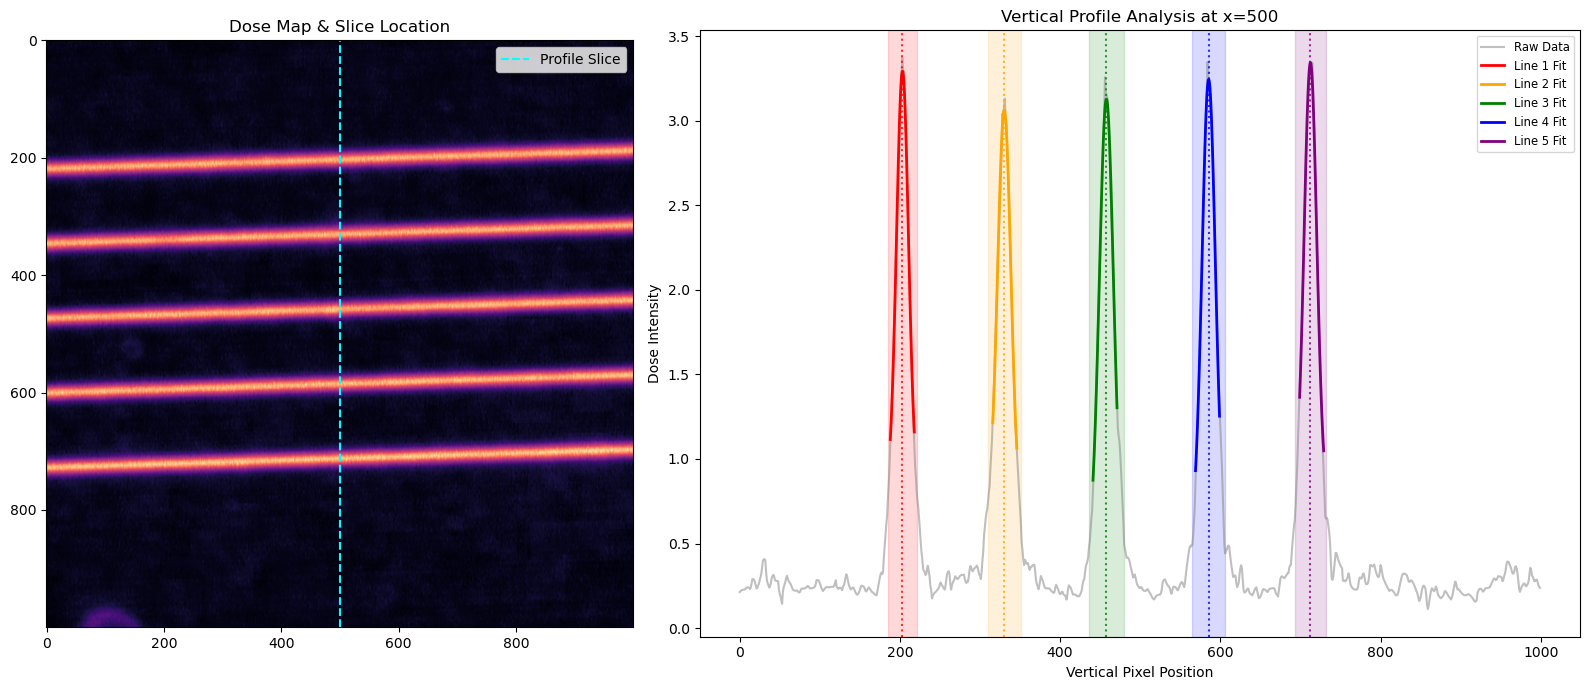

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def gaussian(x, a, mu, sigma, c):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2)) + c

def analyze_dose_spikes(dose_map, x_pos=None):
    rows, cols = dose_map.shape
    if x_pos is None:
        x_pos = cols // 2  # Default to center vertical line
    
    # 1. Extract the vertical profile
    profile = dose_map[:, x_pos]
    x_axis = np.arange(rows)
    
    # 2. Find peaks (spikes)
    # Adjust height/distance based on your specific noise levels
    peaks, _ = find_peaks(profile, height=np.max(profile)*0.3, distance=20)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.5]})
    
    # --- Plot 1: Dose Map with Vertical Line ---
    ax1.imshow(dose_map, cmap='magma')
    ax1.axvline(x_pos, color='cyan', linestyle='--', label='Profile Slice')
    ax1.set_title("Dose Map & Slice Location")
    ax1.legend()

    # --- Plot 2: Profile Analysis ---
    ax2.plot(x_axis, profile, color='gray', alpha=0.5, label='Raw Data')
    ax2.set_title(f"Vertical Profile Analysis at x={x_pos}")
    
    colors = ['red', 'orange', 'green', 'blue', 'purple']
    
    for i, peak in enumerate(peaks):
        # Isolate the data around the peak for fitting (e.g., +/- 15 pixels)
        window = 15
        start, end = max(0, peak-window), min(rows, peak+window)
        x_fit = x_axis[start:end]
        y_fit = profile[start:end]
        
        try:
            # Initial guess: [amplitude, mean, sigma, offset]
            p0 = [profile[peak], peak, 5, np.min(profile)]
            popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0)
            a, mu, sigma, c = popt
            
            # Generate Gaussian curve for plotting
            x_high_res = np.linspace(start, end, 100)
            y_gauss = gaussian(x_high_res, *popt)
            
            # Calculate 2.5 Sigma boundaries
            lower_bound = mu - 2.5 * abs(sigma)
            upper_bound = mu + 2.5 * abs(sigma)
            
            # Plotting
            color = colors[i % len(colors)]
            ax2.plot(x_high_res, y_gauss, color=color, lw=2, label=f'Line {i+1} Fit')
            ax2.axvspan(lower_bound, upper_bound, color=color, alpha=0.15)
            ax2.axvline(mu, color=color, linestyle=':', alpha=0.8)
            
            print(f"Line {i+1}: Center={mu:.2f}, Sigma={abs(sigma):.2f}, 2.5σ Width={5*abs(sigma):.2f}")
            
        except Exception as e:
            print(f"Could not fit peak at {peak}: {e}")

    ax2.set_xlabel("Vertical Pixel Position")
    ax2.set_ylabel("Dose Intensity")
    ax2.legend(loc='upper right', fontsize='small')
    
    plt.tight_layout()
    plt.show()

# Execution:
analyze_dose_spikes(dose_map)

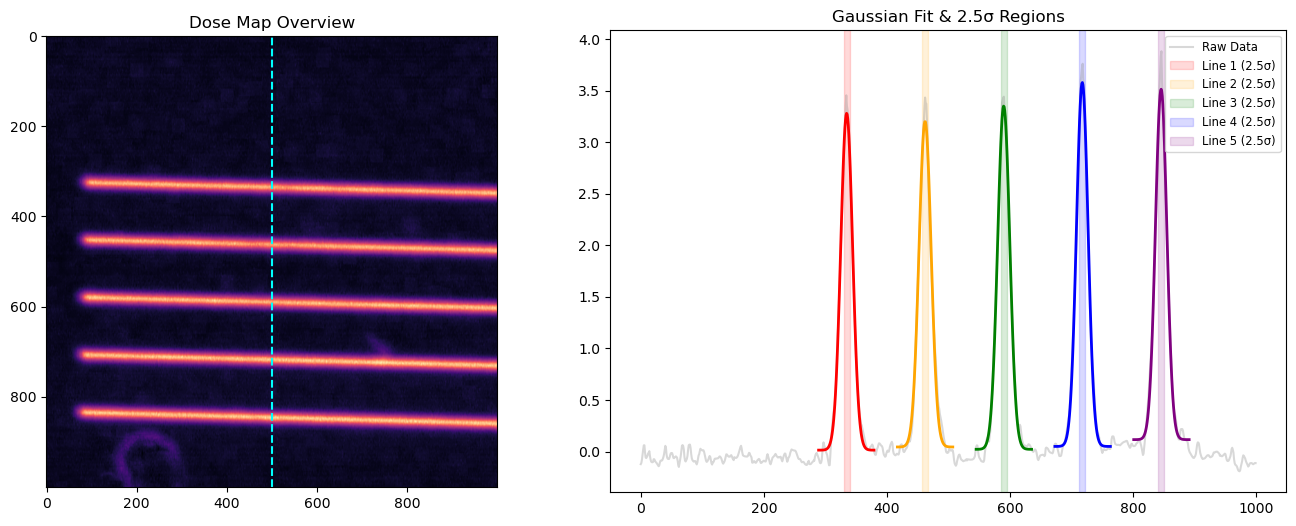

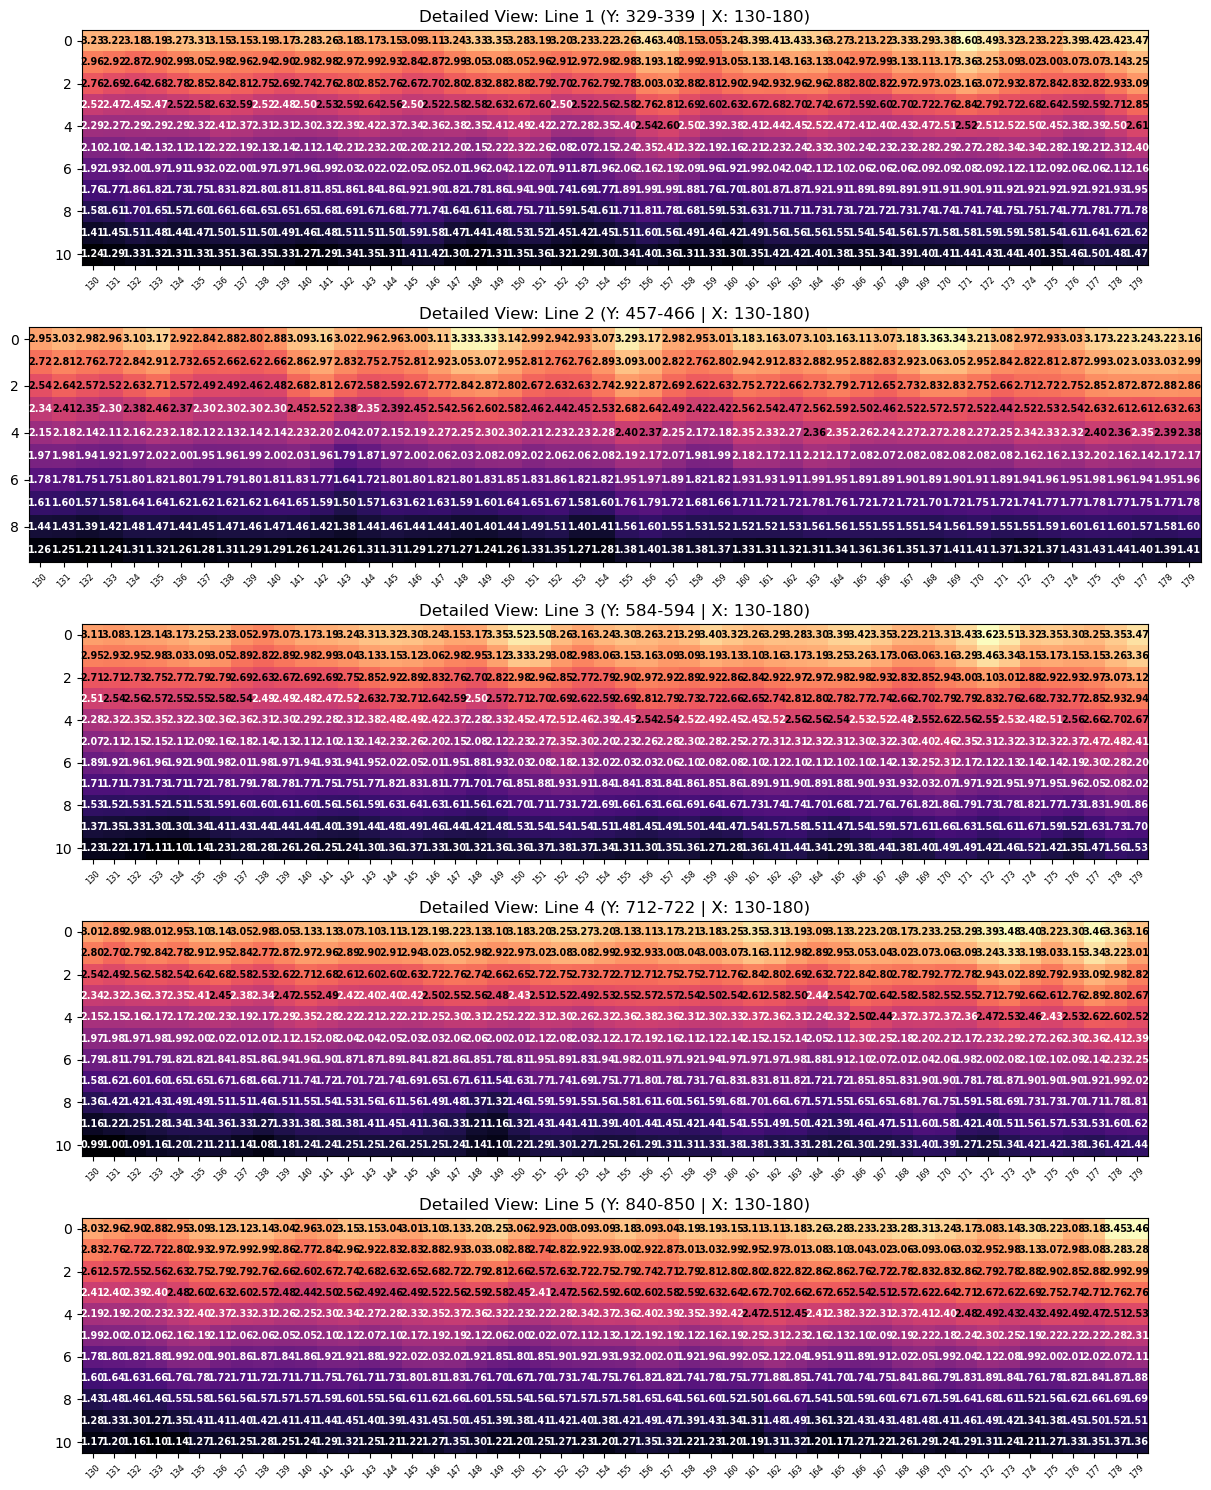

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def gaussian(x, a, mu, sigma, c):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2)) + c

def analyze_dose_combined(dose_map, x_pos=None, x_start=100, x_range=50):
    rows, cols = dose_map.shape
    if x_pos is None:
        x_pos = cols // 2
    
    # 1. Vertical Profile & Peak Finding
    profile = dose_map[:, x_pos]
    x_axis = np.arange(rows)
    peaks, _ = find_peaks(profile, height=np.max(profile)*0.3, distance=20)
    
    # --- FIGURE 1: Overview & Gaussian Fitting ---
    fig1, (ax_map, ax_prof) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.5]})
    ax_map.imshow(dose_map, cmap='magma')
    ax_map.axvline(x_pos, color='cyan', linestyle='--', label='Profile Slice')
    ax_map.set_title("Dose Map Overview")
    
    ax_prof.plot(x_axis, profile, color='gray', alpha=0.3, label='Raw Data')
    
    # Store bounds for the heatmap strips
    strip_bounds = []
    colors = ['red', 'orange', 'green', 'blue', 'purple']

    for i, peak in enumerate(peaks):
        window = 45
        start, end = max(0, peak-window), min(rows, peak+window)
        x_fit, y_fit = x_axis[start:end], profile[start:end]
        
        try:
            p0 = [profile[peak], peak, 5, np.min(profile)]
            popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0)
            a, mu, sigma, c = popt
            mu = mu 
            # Calculate 2.5 Sigma boundaries
            lb, ub = mu +  - .5 * abs(sigma), mu + .5 * abs(sigma)
            strip_bounds.append((int(lb), int(ub)))
            
            # Plotting fits
            color = colors[i % len(colors)]
            x_high = np.linspace(start, end, 100)
            ax_prof.plot(x_high, gaussian(x_high, *popt), color=color, lw=2)
            ax_prof.axvspan(lb, ub, color=color, alpha=0.15, label=f'Line {i+1} (2.5σ)')
        except:
            continue

    ax_prof.set_title("Gaussian Fit & 2.5σ Regions")
    ax_prof.legend(loc='upper right', fontsize='small')

    # --- FIGURE 2: Detailed Heatmap Strips ---
    # Creating a strip for each detected line
    num_strips = len(strip_bounds)
    fig2, axes = plt.subplots(num_strips, 1, figsize=(20, 3 * num_strips))
    if num_strips == 1: axes = [axes]

    x_end = x_start + x_range
    
    for i, (y_min, y_max) in enumerate(strip_bounds):
        # Slice the strip based on Gaussian bounds and requested x-range
        strip = dose_map[y_min:y_max+1, x_start:x_end]
        ax = axes[i]
        
        # Plot Heatmap
        im = ax.imshow(strip, cmap='magma', interpolation='nearest', aspect='equal')
        
        # Overlay Pixel Values
        for (y_idx, x_idx), val in np.ndenumerate(strip):
            # Dynamic text color for readability
            txt_color = "black" if val > (np.max(strip) * 0.7) else "white"
            ax.text(x_idx, y_idx, f'{val:.2f}', ha='center', va='center', 
                    color=txt_color, fontsize=7, fontweight='bold')
        
        ax.set_title(f"Detailed View: Line {i+1} (Y: {y_min}-{y_max} | X: {x_start}-{x_end})")
        ax.set_xticks(np.arange(x_range))
        ax.set_xticklabels(np.arange(x_start, x_end), rotation=45, fontsize=6)

    plt.tight_layout()
    plt.show()

# Run the analysis
analyze_dose_combined(dose_map , x_start=130, x_range=50)

In [38]:
def calculate_physical_dimensions(width_px, height_px, dpi):
    """
    Calculates pixel size and total image dimensions in millimeters.
    
    Args:
        width_px (int): Width of the image in pixels.
        height_px (int): Height of the image in pixels.
        dpi (float): Dots Per Inch of the image/scanner.
        
    Returns:
        dict: Physical measurements in mm.
    """
    # 1 inch = 25.4 mm
    MM_PER_INCH = 25.4
    
    # Calculate the size of a single pixel in mm
    # (Since pixels are typically square, this applies to both height and width)
    pixel_size_mm = MM_PER_INCH / dpi
    
    # Calculate total dimensions
    width_mm = (width_px / dpi) * MM_PER_INCH
    height_mm = (height_px / dpi) * MM_PER_INCH
    
    return {
        "pixel_size_mm": round(pixel_size_mm, 4),
        "total_width_mm": round(width_mm, 2),
        "total_height_mm": round(height_mm, 2),
        "area_mm2": round(width_mm * height_mm, 2)
    }

# Example usage for a high-res film scan (e.g., 300 DPI)
image_stats = calculate_physical_dimensions(width_px=1000, height_px=800, dpi=300)

print(f"Single Pixel Size: {image_stats['pixel_size_mm']} mm")
print(f"Total Dimensions: {image_stats['total_width_mm']} x {image_stats['total_height_mm']} mm")

Pixel Pitch: 0.003969 mm
Digital Resolution: 31872 x 8384 pixels
Physical Size: 126.49 x 33.27 mm


In [39]:
results['pixel_size_mm'] ** 2

1.5752961000000003e-05

Metrology Result: Offset=-0.0242, Sigma=6.80px
18502463.65815141
[1.87808296 0.23518381]


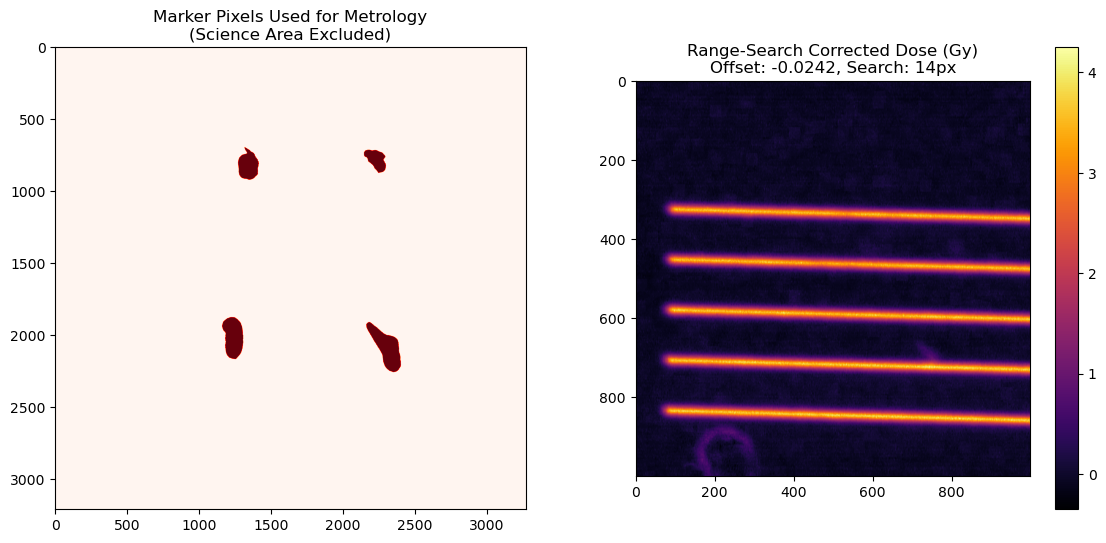

4.248742359287356
-0.3521359031428416


In [67]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import curve_fit

# ==========================================
# 1. CORE MATH & UTILITIES
# ==========================================

def gaussian(x, a, x0, sigma, offset):
    """Gaussian model for marker profile fitting."""
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

import cv2
import numpy as np

def detect_red_mask(image_bgr, sensitivity=1.0, min_area=5):
    """
    Detects red regions, filters by sensitivity and minimum area,
    and returns a clean binary mask.
    """
    # 1. Handle non-uint8 images (Normalization)
    if image_bgr.dtype != np.uint8:
        img_min, img_max = image_bgr.min(), image_bgr.max()
        img_norm = (image_bgr.astype(np.float32) - img_min) / (img_max - img_min + 1e-5)
        image_bgr_8 = (img_norm * 255).astype(np.uint8)
    else:
        image_bgr_8 = image_bgr

    # 2. Convert to HSV
    hsv = cv2.cvtColor(image_bgr_8, cv2.COLOR_BGR2HSV)

    # 3. Define sensitivity-based ranges
    low_sat = max(40, int(70 / sensitivity))
    hue_range = int(10 * sensitivity)
    
    # Threshold both red ranges (wrap-around)
    mask1 = cv2.inRange(hsv, np.array([0, low_sat, 50]), np.array([hue_range, 255, 255]))
    mask2 = cv2.inRange(hsv, np.array([180 - hue_range, low_sat, 50]), np.array([180, 255, 255]))
    mask = cv2.bitwise_or(mask1, mask2)

    # 4. Clean up initial noise (Opening)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    # 5. Filter by Area (The "Process" from the second function)
    # Find all connected blobs
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create an empty black mask to redraw only valid contours
    filtered_mask = np.zeros_like(mask)
    
    for cnt in contours:
        if cv2.contourArea(cnt) >= min_area:
            # Draw the valid "large" blobs back onto the filtered mask
            cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    # 6. Optional: Final Closing to fill small internal holes in the valid blobs
    return cv2.morphologyEx(filtered_mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

def scanner_to_OD(pv: np.ndarray, max_val: float = (2**16 - 1)) -> np.ndarray:
    pv = pv.astype(np.float64)
    pv = np.clip(pv, 1, max_val)
    return np.log10(max_val / pv)

def dose_Calculation_from_OD_diff(OD_diff):
    a, b, c, d = 8.7705, -8.0102, 9.3871, -0.5839
    return a * OD_diff**3 + b * OD_diff**2 + c * OD_diff + d

# ==========================================
# 2. GAUSSIAN METROLOGY LOGIC
# ==========================================

def get_marker_metrology(od_diff, marker_mask, num_profiles=20):
    """Fits Gaussians to marker profiles to find Offset and Jitter (Sigma)."""
    h, w = od_diff.shape
    offsets = []
    sigmas = []

    # Find rows that contain marker pixels
    marker_rows = np.where(np.any(marker_mask, axis=1))[0]
    if len(marker_rows) < num_profiles: return 0.0, 1.0

    # Sample profiles across the markers
    row_indices = np.linspace(0, len(marker_rows)-1, num_profiles, dtype=int)
    
    for r_idx in marker_rows[row_indices]:
        profile = od_diff[r_idx, :]
        # Focus the fit only on the part of the profile where the mask is active
        cols = np.where(marker_mask[r_idx, :])[0]
        if len(cols) < 5: continue
        
        # Center the search window around the marker
        c_min, c_max = max(0, cols.min()-10), min(w, cols.max()+10)
        x = np.arange(c_min, c_max)
        y = profile[c_min:c_max]
        
        # Initial Guess [Amp, Center, Sigma, Offset]
        p0 = [np.max(y)-np.min(y), x[np.argmax(y)], 2.0, np.min(y)]
        try:
            popt, _ = curve_fit(gaussian, x, y, p0=p0, maxfev=800)
            sigmas.append(abs(popt[2]))
            offsets.append(popt[3])
        except:
            continue

    avg_offset = np.median(offsets) if offsets else 0.0
    avg_sigma = np.median(sigmas) if sigmas else 1.0
    return avg_offset, avg_sigma

# ==========================================
# 3. UPDATED PIPELINE
# ==========================================

def run_marker_spike_analysis(path_pre, file_pre, path_post, file_post, M_rigid, P_pre, P_post):
    # --- Step 1: Load and Align Full Color ---
    img_pre_bgr = cv2.imread(f"{path_pre}/{file_pre}", cv2.IMREAD_UNCHANGED)
    img_post_bgr = cv2.imread(f"{path_post}/{file_post}", cv2.IMREAD_UNCHANGED)
    h, w = img_pre_bgr.shape[:2]
    img_post_aligned = cv2.warpAffine(img_post_bgr, M_rigid, (w, h), flags=cv2.INTER_LINEAR)

    # --- Step 2: Full OD Calculation (Blue Channel) ---
    pre_clean = img_pre_bgr[..., 0].astype(np.float64)
    post_clean = img_post_aligned[..., 0].astype(np.float64)

    od_pre_full = np.polyval(P_pre, scanner_to_OD(pre_clean))
    od_post_full = np.polyval(P_post, scanner_to_OD(post_clean))
    od_diff_raw = od_post_full - od_pre_full

    # --- Step 3: Marker Masking (Excluding Science Area) ---
    marker_mask = detect_red_mask(img_post_aligned,sensitivity=.6, min_area=30) > 0
    cy, cx = h // 2, w // 2
    
    # Range constraints
    zone_mask = np.zeros_like(marker_mask)
    zone_mask[max(0, cy-4000):min(h, cy+4000), max(0, cx-4000):min(w, cx+4000)] = True
    
    # Define Science Hole (1000 to 2500)
    # science_hole = np.zeros_like(marker_mask)
    # science_hole[1000:2500, 1000:2500] = True
    
    # Final Metrology Mask
    metrology_mask = zone_mask & marker_mask 

    # --- Step 4: Gaussian Metrology ---
    # Find the background offset and the spatial jitter (sigma) from markers
    subtraction_offset, jitter_sigma = get_marker_metrology(od_diff_raw, metrology_mask)
    print(f"Metrology Result: Offset={subtraction_offset:.4f}, Sigma={jitter_sigma:.2f}px")

    # --- Step 5: Local Range Search (to minimize jitter spikes) ---
    # We use a kernel size based on 2*sigma to find the best local alignment match
    search_size = max(1, int(np.ceil(jitter_sigma * 2)))
    kernel = np.ones((search_size*2+1, search_size*2+1), np.uint8)
    pre_data, post_aligned = get_clean_aligned_data(pre, post, M_rigid)
    od_pre_full = np.polyval(P_pre, scanner_to_OD(pre_data))
    print(np.sum(od_pre_full))
    print(P_pre)
    od_post_full = np.polyval(P_post, scanner_to_OD(post_aligned))
    
    # 'Erode' on post-OD finds the lowest local value (best potential match for Pre)
    from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter

    # 1. Create the 'maximized' version of your second array
    # This finds the max within a 16-element window for every position
    od_pre_full =minimum_filter(od_pre_full, size=search_size*2+1) 


    
    # --- Step 6: Apply to Science Region (1000:2500) ---
    od_pre_sci = od_pre_full[1000:2000, 1000:2000]
    od_post_sci = od_post_full[1000:2000, 1000:2000]
    
    # Net OD = (Local Optimized Post - Pre) - Background Offset
    od_diff_science = (od_post_sci - od_pre_sci) - subtraction_offset
    
    dose_map = dose_Calculation_from_OD_diff(od_diff_science) 

    # --- Step 7: Visualization ---
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    ax[0].imshow(metrology_mask, cmap='Reds')
    ax[0].set_title("Marker Pixels Used for Metrology\n(Science Area Excluded)")
    
    im = ax[1].imshow(dose_map, cmap='inferno')
    ax[1].set_title(f"Range-Search Corrected Dose (Gy)\nOffset: {subtraction_offset:.4f}, Search: {search_size}px")
    plt.colorbar(im, ax=ax[1])
    plt.show()

    return dose_map
    

dose_map= run_marker_spike_analysis(path_pre, file_pre, path_post, file_post, M_rigid, my_dict_pre['P'], my_dict_post['P'])
print(np.max(dose_map))
print(np.min(dose_map))

In [70]:
import numpy as np
import cv2
from scipy.signal import find_peaks

def analyze_dose_profiles(dose_map, window_size=15):
    h, w = dose_map.shape
    
    # 1. Find the approximate Y-locations of the lines
    vertical_profile = np.mean(dose_map, axis=1)
    # distance=50 ensures we don't pick the same line twice
    line_y_approx, _ = find_peaks(vertical_profile, height=np.mean(vertical_profile), distance=50)
    
    peak_values = []
    all_peak_indices = []

    # 2. Follow each line and track the maximum
    for y_start in line_y_approx:
        current_y = y_start
        line_peaks = []
        line_indices = []
        
        for x in range(w):
            # Define search window boundaries
            y_min = max(0, current_y - window_size)
            y_max = min(h, current_y + window_size)
            
            # Find the local max in this column's window
            window = dose_map[y_min:y_max, x]
            if len(window) == 0: continue
            
            local_max_idx = np.argmax(window)
            actual_y = y_min + local_max_idx
            
            line_peaks.append(dose_map[actual_y, x])
            line_indices.append((actual_y, x))
            
            # Update current_y to "follow" the line if it tilts
            current_y = actual_y
            
        peak_values.extend(line_peaks)
        all_peak_indices.append(line_indices)

    # 3. Calculate Valley Dose (Areas outside the peaks)
    # Create a mask of the peaks and dilate it to cover the whole "slope"
    peak_mask = np.zeros_like(dose_map, dtype=np.uint8)
    for line in all_peak_indices:
        for y, x in line:
            peak_mask[y, x] = 255
            
    # Expand the mask to exclude the entire width of the dose lines (e.g., 20px)
    excluded_area = cv2.dilate(peak_mask, np.ones((20, 20), np.uint8))
    valley_mask = cv2.bitwise_not(excluded_area)
    
    # Final Calculations
    avg_peak_dose = np.mean(peak_values)
    avg_valley_dose = np.mean(dose_map[valley_mask > 0])
    
    return avg_peak_dose, avg_valley_dose, valley_mask
avg_peak_dose, avg_valley_dose, valley_mask= analyze_dose_profiles(dose_map)
print(f"Average Peak Dose: {avg_peak_dose:.2f} Gy")
print(f"Average Valley Dose: {avg_valley_dose:.2f} Gy")

Average Peak Dose: 3.35 Gy
Average Valley Dose: 0.22 Gy


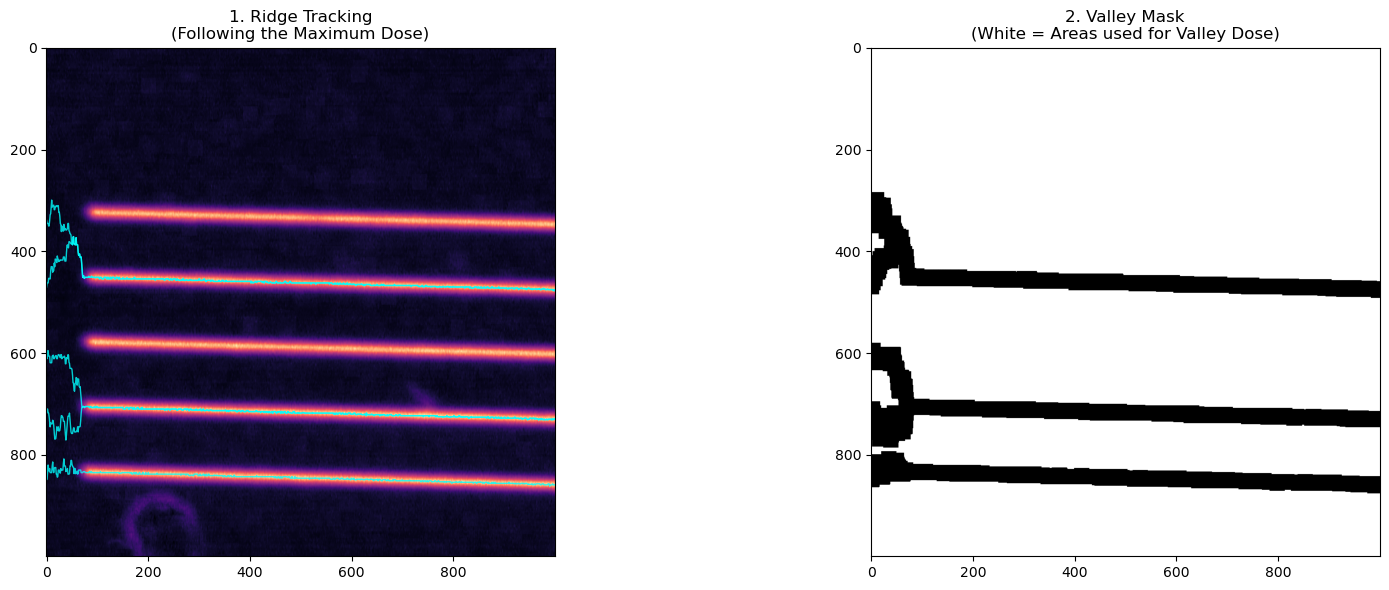

Average Peak Dose: 3.35 Gy
Average Valley Dose: 0.19 Gy


In [139]:
import matplotlib.pyplot as plt

def plot_dose_metrology(dose_map, all_peak_indices, valley_mask, vertical_profile, line_y_approx):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    


    # Panel 2: Ridge Tracking
    # Overlays the tracked peak paths on the original dose map
    axes[0].imshow(dose_map, cmap='magma')
    for line in all_peak_indices:
        y_coords, x_coords = zip(*line)
        axes[0].plot(x_coords, y_coords, color='cyan', linewidth=1, alpha=0.8)
    axes[0].set_title("1. Ridge Tracking\n(Following the Maximum Dose)")

    # Panel 2: Valley Mask
    # Shows exactly which pixels are used for the 'background' calculation
    axes[1].imshow(valley_mask, cmap='gray')
    axes[1].set_title("2. Valley Mask\n(White = Areas used for Valley Dose)")

    plt.tight_layout()
    plt.show()
def analyze_dose_profiles(dose_map, window_size=15):
    h, w = dose_map.shape
    vertical_profile = np.mean(dose_map, axis=1)
    line_y_approx, _ = find_peaks(vertical_profile, height=np.mean(vertical_profile), distance=50)
    
    all_peak_indices = []
    peak_values = []

    for y_start in line_y_approx:
        current_y = y_start
        line_indices = []
        for x in range(w):
            y_min, y_max = max(0, current_y - window_size), min(h, current_y + window_size)
            window = dose_map[y_min:y_max, x]
            if len(window) == 0: continue
            actual_y = y_min + np.argmax(window)
            peak_values.append(dose_map[actual_y, x])
            line_indices.append((actual_y, x))
            current_y = actual_y
        all_peak_indices.append(line_indices)

    peak_mask = np.zeros_like(dose_map, dtype=np.uint8)
    for line in all_peak_indices:
        for y, x in line: peak_mask[y, x] = 255
            
    valley_mask = cv2.bitwise_not(cv2.dilate(peak_mask, np.ones((30, 30), np.uint8)))
    plot_dose_metrology(dose_map, all_peak_indices, valley_mask.astype(np.uint8) * 255, np.mean(dose_map, axis=1), [p[0][0] for p in all_peak_indices])
    return np.mean(peak_values), np.mean(dose_map[valley_mask > 0]), valley_mask, vertical_profile, line_y_approx, all_peak_indices
# To use this with the previous function:
peak_dose, valley_dose, v_mask, v_prof, y_approx, peaks = analyze_dose_profiles(dose_map)

print(f"Average Peak Dose: {peak_dose:.2f} Gy")
print(f"Average Valley Dose: {valley_dose:.2f} Gy")


In [ ]:
import numpy as np
import cv2
from scipy.signal import find_peaks

def find_seeds_with_threshold(dose_map, num_lines=5, window_width=10, min_dose=1.0):
    """Scans for columns where peaks are both distinct and above the threshold."""
    h, w = dose_map.shape
    for x_start in range(0, w // 2, window_width):
        slice_avg = np.mean(dose_map[:, x_start : x_start + window_width], axis=1)
        
        # 'height=min_dose' filters out any peaks that don't reach the target dose
        y_seeds, props = find_peaks(slice_avg, distance=50, height=min_dose)
        
        # We only return the seeds if we find exactly the number of lines expected
        if len(y_seeds) == num_lines:
            return y_seeds, x_start
            
    return None, 0

import numpy as np
import cv2
from scipy.signal import find_peaks

def analyze_dose_profiles_final(dose_map, num_lines=5, window_size=15, min_dose=1.0):
    h, w = dose_map.shape
    
    # --- 1. Scout for starting points (Dose > 1.0) ---
    y_seeds, x_entry = find_seeds_with_threshold(dose_map, num_lines, min_dose=min_dose)
    if y_seeds is None: return None

    all_peak_indices = []
    all_peak_dose = []
    ridge_peak_values = [] # This will store ONLY the values on the ridge lines

    # --- 2. Ridge Tracking (The "Maximum Dose" Line) ---
    for y_start in y_seeds:
        current_y = y_start
        line_indices = []
        for x in range(x_entry + 15, w):
            y_min, y_max = max(0, current_y - window_size), min(h, current_y + window_size)
            window = dose_map[y_min:y_max, x]
            
            if len(window) == 0: break
            
            local_max_idx = np.argmax(window)
            peak_intensity = window[local_max_idx]
            
            # Only track if the dose is above your threshold
            if peak_intensity < min_dose: break
            
            actual_y = y_min + local_max_idx
            
            # COLLECT DATA: Only the specific ridge pixel
            ridge_peak_values.append(peak_intensity)
            line_indices.append((actual_y, x))
          
            
            # Update current_y to follow the line's path
            current_y = actual_y
            
        all_peak_indices.append(line_indices)
        all_peak_dose.append([dose_map[y, x] for y, x in line_indices])

    # --- 3. Create the "After First Strip" Gate ---
    after_first_strip_gate = np.zeros_like(dose_map, dtype=bool)
    if all_peak_indices:
        first_line = all_peak_indices[0]

        last_line = all_peak_indices[-1]
        buffer_below_strip = 25 
        minimum = np.max(first_line[0])
        maximum = np.max(last_line[0])
        print(f"First line starts at Y={minimum}, Last line starts at Y={maximum}")
        for y,x in first_line:
            after_first_strip_gate[minimum + buffer_below_strip:maximum + buffer_below_strip, x] = True
    # --- 4. Build the Valley Mask ---
    peak_mask = np.zeros_like(dose_map, dtype=np.uint8)
    for line in all_peak_indices:
        for y, x in line:
            peak_mask[y, x] = 255
    
    # Exclude area around peaks (slope exclusion)
    excluded_area = cv2.dilate(peak_mask, np.ones((40, 40), np.uint8))
    
    # Valley = (Away from peaks) AND (Below threshold) AND (Spatially after 1st strip)
    valley_mask = (excluded_area == 0) & (dose_map < min_dose) & after_first_strip_gate
    
    # FINAL CALCULATIONS
    # Peak Dose is the average of the exact ridge values collected
    
    avg_peak = np.mean(ridge_peak_values) if ridge_peak_values else 0.0
    avg_valley = np.mean(dose_map[valley_mask]) if np.any(valley_mask) else 0.0
    plot_dose_metrology(dose_map, all_peak_indices, valley_mask.astype(np.uint8) * 255, np.mean(dose_map, axis=1), [p[0][0] for p in all_peak_indices])
    return avg_peak, avg_valley, (valley_mask.astype(np.uint8) * 255), all_peak_indices, all_peak_dose

# To use this with the previous function:
peak_dose, valley_dose, v_mask, all_peaks, ridge_values = analyze_dose_profiles_final(dose_map, num_lines=5, min_dose=1.0)

print(f"Average Peak Dose: {peak_dose:.2f} Gy")
print(f"Average Valley Dose: {valley_dose:.2f} Gy")


NameError: name 'dose_map' is not defined

: 

3.521943196645589
0.2274594809082635


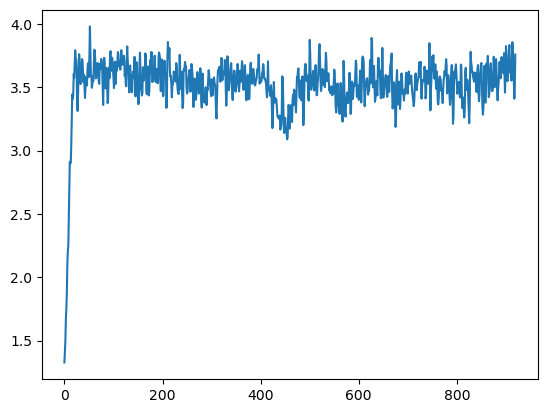

In [117]:
plt.plot(ridge_values[0])
print(np.mean(ridge_values[0]))
print(np.std(ridge_values[0]))